# FACULTAD DE CIENCIAS - CIENCIA DE LA COMPUTACION
---
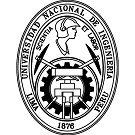
---
# TEMA: Análisis multicanal de archivo EDF 

---

#

### [1] Descarga de la librerias requeridas MNE, pandas,PyQt5

In [1]:
#instalacion de paquetes para la lectura de los archivos.edf
import sys
print(sys.executable)

!{sys.executable} -m pip install mne
!{sys.executable} -m pip install pandas
!pip install pandas


#para diagramas iterativos
!pip install PyQt5

# permite crear elementos interactivos (widgets) dentro de Jupyter Notebook y JupyterLab
!pip install ipywidgets

c:\Users\Usuario\AppData\Local\Programs\Python\Python310\python.exe



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


### [2] Revision del listado de pacientes que se tiene la data para estudio

In [2]:
import pandas as pd

# Ruta del archivo CSV con la información general
#csv_path = r"D:\CICLO 2025-2 UNI\PROGRAMACION_PARALELA\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\subject_info.csv"
csv_path = r"D:\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\subject_info.csv"

# Cargar tabla de pacientes
df = pd.read_csv(csv_path)

print("==== LISTA DE PACIENTES DISPONIBLES EN LA BASE DE DATOS ====")
for i, row in df.iterrows():
    print(f"Paciente {i} -> {row['patient_id']}")
    
print("\nCaracteristicas de los pacientes:")
df

==== LISTA DE PACIENTES DISPONIBLES EN LA BASE DE DATOS ====
Paciente 0 -> PN00
Paciente 1 -> PN01
Paciente 2 -> PN03
Paciente 3 -> PN05
Paciente 4 -> PN06
Paciente 5 -> PN07
Paciente 6 -> PN09
Paciente 7 -> PN10
Paciente 8 -> PN11
Paciente 9 -> PN12
Paciente 10 -> PN13
Paciente 11 -> PN14
Paciente 12 -> PN16
Paciente 13 -> PN17

Caracteristicas de los pacientes:


,patient_id,age_years,gender,seizure,localization,lateralization,eeg_channel,number_seizures,rec_time_minutes
0,PN00,55,Male,IAS,T,R,29,5,198
1,PN01,46,Male,IAS,T,L,29,2,809
2,PN03,54,Male,IAS,T,R,29,2,752
3,PN05,51,Female,IAS,T,L,29,3,359
4,PN06,36,Male,IAS,T,L,29,5,722
5,PN07,20,Female,IAS,T,L,29,1,523
6,PN09,27,Female,IAS,T,L,29,3,410
7,PN10,25,Male,FBTC,F,Bilateral,20,10,1002
8,PN11,58,Female,IAS,T,R,29,1,145
9,PN12,71,Male,IAS,T,L,29,4,246


### [3] Visualizacion de los episodios de paciente selecionado

---

### Paciente Selecionado --> PN0

Cambiar la ruta para ver los episodios del paciente selecionado

\PN0__\Seizures-list-PN0__.txt

---

In [3]:
import re
from datetime import time

#txt_path = r"D:\CICLO 2025-2 UNI\PROGRAMACION_PARALELA\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00\Seizures-list-PN00.txt"
txt_path = r"D:\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00\Seizures-list-PN00.txt"

def parse_time(t):
    """Convierte formatos tipo '19.39.33' a (segundos, objeto time)."""
    t = t.strip()
    h, m, s = t.split(".")
    h = int(h); m = int(m); s = int(s)
    seconds = h*3600 + m*60 + s
    hora_obj = time(h, m, s)
    return seconds, hora_obj

seizures = []
current = {}

with open(txt_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()

        if line.startswith("Seizure n"):
            if current:
                seizures.append(current)

            # Extraer número aunque venga como "n1" o "n 1"
            parte = line.split()[-1]   # puede ser "1" o "n1"
            num = re.sub(r"\D", "", parte)  # quita todo lo que no es dígito

            if num == "":
                raise ValueError(f"No pude extraer número de: {line}")

            current = {"n": int(num)}

        elif line.startswith("File name:"):
            current["edf"] = line.split(":")[1].strip()

        elif line.startswith("Registration start time:"):
            t_str = line.split(":")[1].strip()
            secs, hora = parse_time(t_str)
            current["reg_start"] = secs
            current["reg_start_h"] = hora

        elif line.startswith("Registration end time:"):
            t_str = line.split(":")[1].strip()
            secs, hora = parse_time(t_str)
            current["reg_end"] = secs
            current["reg_end_h"] = hora

        elif line.startswith("Seizure start time:"):
            t_str = line.split(":")[1].strip()
            secs, hora = parse_time(t_str)
            current["sei_start"] = secs
            current["sei_start_h"] = hora

        elif line.startswith("Seizure end time:"):
            t_str = line.split(":")[1].strip()
            secs, hora = parse_time(t_str)
            current["sei_end"] = secs
            current["sei_end_h"] = hora

if current:
    seizures.append(current)

# Calcular tiempos relativos
for s in seizures:
    s["relative_start_sec"] = s["sei_start"] - s["reg_start"]
    s["relative_end_sec"]  = s["sei_end"] - s["reg_start"]
    s["duration_sec"]      = s["relative_end_sec"] - s["relative_start_sec"]

# Imprimir todo
for s in seizures:
    print("========================================================")
    print(f"Seizure n°:                        {s['n']}")
    print(f"EDF file:                          {s['edf']}")

    print("\n--- REGISTRO (toma de muestra EEG) ---")
    print(f"Inicio registro (hora real):       {s['reg_start_h']}")
    print(f"Fin registro (hora real):          {s['reg_end_h']}")
    print(f"Inicio registro (abs seg):         {s['reg_start']} s")
    print(f"Fin registro (abs seg):            {s['reg_end']} s")

    print("\n--- EPISODIO EPILÉPTICO ---")
    print(f"Inicio episodio (hora real):       {s['sei_start_h']}")
    print(f"Fin episodio (hora real):          {s['sei_end_h']}")
    print(f"Inicio episodio (abs seg):         {s['sei_start']} s")
    print(f"Fin episodio (abs seg):            {s['sei_end']} s")

    print("")
    print(f"Inicio episodio (relativo):        {s['relative_start_sec']} s")
    print(f"Fin episodio (relativo):           {s['relative_end_sec']} s")
    print(f"Duración del episodio:             {s['duration_sec']} s")
    print("========================================================")


Seizure n°:                        1
EDF file:                          PN00-1.edf

--- REGISTRO (toma de muestra EEG) ---
Inicio registro (hora real):       19:39:33
Fin registro (hora real):          20:22:58
Inicio registro (abs seg):         70773 s
Fin registro (abs seg):            73378 s

--- EPISODIO EPILÉPTICO ---
Inicio episodio (hora real):       19:58:36
Fin episodio (hora real):          19:59:46
Inicio episodio (abs seg):         71916 s
Fin episodio (abs seg):            71986 s

Inicio episodio (relativo):        1143 s
Fin episodio (relativo):           1213 s
Duración del episodio:             70 s
Seizure n°:                        2
EDF file:                          PN00-2.edf

--- REGISTRO (toma de muestra EEG) ---
Inicio registro (hora real):       02:18:17
Fin registro (hora real):          02:56:19
Inicio registro (abs seg):         8297 s
Fin registro (abs seg):            10579 s

--- EPISODIO EPILÉPTICO ---
Inicio episodio (hora real):       02:38:37
Fin ep

### [4] Carga del archivo EDF y exploración de metadatos de un Episodio 

En esta sección se carga el archivo EDF usando `mne.io.read_raw_edf` y se inspecciona:

- Número de canales.
- Frecuencia de muestreo.
- Etiquetas de canales.
- Duración del registro.

En la ruta seleccionar, la ruta y el archivo .edf del episodio a analizar:

edf_path =  r"D:\CICLO 2025-2 UNI\PROGRAMACION_PARALELA\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN0__\PN0__-__.edf"



---

Carga de la metadata para el paciente PN00, el primer episodio (Seizure 1)

---

In [5]:
import mne
import numpy as np
import pandas as pd
#edf_path =  r"D:\CICLO 2025-2 UNI\PROGRAMACION_PARALELA\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00\PN00-1.edf"
edf_path = r"D:\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00\PN00-1.edf"


# Carga del archivo EDF
raw = mne.io.read_raw_edf(edf_path, preload=True)

print(raw)
print("\n######  INFO DETALLADA  ######")
print(raw.info)

# Información básica
sfreq = raw.info["sfreq"]               # frecuencia de muestreo
ch_names = raw.info["ch_names"]         # nombres de canales
n_channels = len(ch_names)              # número de canales
n_samples = raw.n_times                 # número de muestras por canal
duration_sec = n_samples / sfreq        # duración total en segundos

print("\nFrecuencia de muestreo (Hz):", sfreq)
print("Número de canales:", n_channels)
print("Número de muestras:", n_samples)
print("Duración (s):", duration_sec)
print("Primeros 10 canales:", ch_names[:min(10, n_channels)])


raw 

Extracting EDF parameters from D:\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00\PN00-1.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1343999  =      0.000 ...  2624.998 secs...


C:\Users\Usuario\AppData\Local\Temp\ipykernel_3148\2118295523.py:9: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_3148\2118295523.py:9: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_3148\2118295523.py:9: RuntimeWarning: Highpass cutoff frequency 15.91549 is greater than lowpass cutoff frequency 15.0, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(edf_path, preload=True)


<RawEDF | PN00-1.edf, 35 x 1344000 (2625.0 s), ~358.9 MiB, data loaded>

######  INFO DETALLADA  ######
<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fp1, EEG F3, EEG C3, EEG P3, EEG O1, EEG F7, EEG T3, EEG T5, ...
 chs: 35 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 256.0 Hz
 meas_date: 2016-01-01 19:39:33 UTC
 nchan: 35
 projs: []
 sfreq: 512.0 Hz
 subject_info: <subject_info | his_id: >
>

Frecuencia de muestreo (Hz): 512.0
Número de canales: 35
Número de muestras: 1344000
Duración (s): 2625.0
Primeros 10 canales: ['EEG Fp1', 'EEG F3', 'EEG C3', 'EEG P3', 'EEG O1', 'EEG F7', 'EEG T3', 'EEG T5', 'EEG Fc1', 'EEG Fc5']


<RawEDF | PN00-1.edf, 35 x 1344000 (2625.0 s), ~358.9 MiB, data loaded>

---

Pasamos la data de un paciente a una matriz de numpy

---

In [6]:
# Obtiene los datos como matriz NumPy: shape = (n_channels, n_samples)
data, times = raw.get_data(return_times=True)

print("data.shape =", data.shape)
print("times.shape =", times.shape)
print("Tiempo inicial:", times[0], "s")
print("Tiempo final:", times[-1], "s")


data.shape = (35, 1344000)
times.shape = (1344000,)
Tiempo inicial: 0.0 s
Tiempo final: 2624.998046875 s


### Carga de librerias requeridas, y rura de archivo de estudio - Paciente 0

In [7]:
# Imports principales
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Para que los gráficos se vean dentro del notebook
%matplotlib inline

# Ruta del archivo EDF (la que tú indicaste)
#edf_path = r"D:\CICLO 2025-2 UNI\PROGRAMACION_PARALELA\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00\PN00-1.edf"
edf_path = r"D:\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00\PN00-1.edf"
# Configuración de logs de MNE
mne.set_log_level("INFO")

print("Ruta EDF:", edf_path)

Ruta EDF: D:\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00\PN00-1.edf


## [5] Visualización dinamica de todos los canales con todos los puntos

A continuación, se construye una figura de Matplotlib con todas las señales, la navegacion en ella es dinamica


In [8]:
# Gráfico interactivo de todos los canales
# Puedes ajustar `duration` (ventana en segundos) y `n_channels` visibles en pantalla.
%matplotlib qt
raw.plot(duration=10.0, n_channels=n_channels, scalings="auto");


Using matplotlib as 2D backend.


Channels marked as bad:
none


## [6] Visualización estática de todos los canales con todos los puntos

A continuación, se construye una figura de Matplotlib con:

- Un subplot por canal.
- Eje x = tiempo (segundos).
- Eje y = amplitud de la señal (unidades del EDF).

In [9]:
import mne
import matplotlib.pyplot as plt

raw = mne.io.read_raw_edf(edf_path, preload=True)
data, times = raw.get_data(), raw.times
ch_names = raw.ch_names
n_channels = data.shape[0]

fig, axes = plt.subplots(
    n_channels, 1,
    figsize=(24, 14),
    sharex=True
)

for i in range(n_channels):
    axes[i].plot(times, data[i], linewidth=0.8)
    axes[i].set_ylabel(ch_names[i], rotation=0, labelpad=40)

# Ajustes por defecto que deseas
plt.subplots_adjust(
    top=0.955,
    bottom=0.055,
    left=0.05,
    right=0.995,
    hspace=0.200,
    wspace=0.200
)

# Quitar los números del eje Y
for ax in axes:
    ax.set_yticks([])
    ax.tick_params(axis='y', length=0)

plt.xlabel("Tiempo [s]")
plt.suptitle("Todos los canales con todos los puntos", fontsize=16)
plt.show()


Extracting EDF parameters from D:\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00\PN00-1.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1343999  =      0.000 ...  2624.998 secs...


C:\Users\Usuario\AppData\Local\Temp\ipykernel_3148\4282602163.py:4: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_3148\4282602163.py:4: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_3148\4282602163.py:4: RuntimeWarning: Highpass cutoff frequency 15.91549 is greater than lowpass cutoff frequency 15.0, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(edf_path, preload=True)


## [7] Estadísticas básicas por canal

Se calculan:

- Media por canal.
- Desviación estándar por canal.
- Valor mínimo y máximo.

Esto da una primera idea de la escala de cada canal y posibles artefactos.


In [11]:
# Estadísticas básicas por canal
means = data.mean(axis=1)
stds = data.std(axis=1)
mins = data.min(axis=1)
maxs = data.max(axis=1)

stats_df = pd.DataFrame({
    "canal": ch_names,
    "media": means,
    "desviacion_std": stds,
    "minimo": mins,
    "maximo": maxs
})

stats_df

,canal,media,desviacion_std,minimo,maximo
0,EEG Fp1,4.803523e-06,3.403837e-05,-0.000710,0.000795
1,EEG F3,5.318128e-06,2.645774e-05,-0.000602,0.000633
2,EEG C3,3.131167e-06,2.904585e-05,-0.000569,0.000300
3,EEG P3,3.990579e-06,4.022246e-05,-0.000657,0.000991
4,EEG O1,3.663936e-06,1.060350e-04,-0.001187,0.003182
5,EEG F7,7.100435e-06,4.015560e-05,-0.000654,0.000354
6,EEG T3,4.914065e-06,3.526235e-05,-0.000714,0.000315
7,EEG T5,8.439295e-06,2.891023e-05,-0.000486,0.000333
8,EEG Fc1,5.140642e-06,2.755394e-05,-0.000619,0.000281
9,EEG Fc5,2.877245e-06,3.152580e-05,-0.000596,0.000364


## [8] Selección de Canales Representativos para la Detección de Crisis Epilépticas

La electroencefalografía (EEG) registra diferencias de potencial en el cuero cabelludo mediante una red
de electrodos organizados usualmente bajo el sistema internacional **10–20** o sus extensiones.
Cada electrodo proporciona una señal eléctrica en unidades de microvoltios (µV) que refleja la actividad
sincrónica de grandes poblaciones neuronales corticales.

En el análisis de episodios epilépticos, no todos los canales aportan la misma relevancia clínica.
La elección de *canales representativos* se basa en la neurofisiología de los generadores de descargas
epileptiformes y en la localización típica de los focos más comunes.  
A continuación se justifica la selección utilizada.

### 1. Canales temporales (T3, T4, T5, T6)

Los lóbulos temporales son la región más frecuentemente asociada a la epilepsia focal,
especialmente en el caso de la **epilepsia del lóbulo temporal (TLE)**.  
Por ello, los canales:
- `T3` y `T5` en el hemisferio izquierdo,
- `T4` y `T6` en el hemisferio derecho,

constituyen los electrodos más sensibles para detectar:
- complejos punta–onda,
- actividad rítmica tipo theta o delta,
- ondas agudas y polipuntas,
- cambios electrográficos súbitos de alta amplitud.

Por esta razón, estos canales son los **más representativos** para la observación de crisis.

### 2. Canales frontales (Fp1, Fp2, F3, F4, F7, F8)

La región frontal participa en:
- diseminación rápida de la actividad epileptiforme,
- crisis motoras de inicio frontal,
- cambios de alta frecuencia al inicio ictal.

Los canales prefrontales (`Fp1`, `Fp2`) y frontales (`F3`, `F4`, `F7`, `F8`)
permiten detectar:
- actividad rítmica de alta frecuencia,
- patrones de reclutamiento,
- propagación anterior de actividad temporal.

Aunque no siempre son los generadores primarios, aportan un contexto espacial esencial
para la identificación del inicio y diseminación de la crisis.

### 3. Canales centrales (C3, C4, Cz)

Los electrodos centrales se ubican sobre la corteza somatosensorial.
Son útiles para:
- crisis motoras,
- propagación rápida hacia áreas perisilvianas,
- análisis de simetría interhemisférica.

En casos de crisis focales que se diseminan hacia corteza motora, estos canales
presentan incrementos claros en amplitud o ritmicidad.

### 4. Canales parietales (P3, P4, Pz)

Los electrodos parietales ofrecen sensibilidad a:
- propagación posterior,
- patrones de realce parieto–occipital,
- descargas secundarias de actividad temporal o frontal.

La observación de estos canales permite contextualizar el origen y la dirección
del flujo eléctrico cortical durante la crisis.

### 5. Canales occipitales (O1, O2)

Aunque la epilepsia occipital es menos frecuente que la temporal o frontal,
los electrodos `O1` y `O2` son relevantes porque:
- revelan descargas punta–onda posteriores,
- ayudan a verificar si una crisis detectada es generalizada o focal posterior,
- permiten evaluar si existe propagación hacia la región visual.

### 6. Fundamentación de la selección final

Dado que el objetivo del análisis es **detectar y visualizar episodios epilépticos**,
se priorizan los canales que clínicamente aportan mayor sensibilidad:

- **Temporales:** máxima prioridad por su asociación directa con epilepsia focal.
- **Frontales:** esenciales para identificar propagación anterior e inicio frontal.
- **Centrales:** útiles para crisis motoras y para interpretar simetrías.
- **Parietales:** permiten evaluar propagación posterior.
- **Occipitales:** completan el mapa espacial, especialmente para descargas posteriores.

Esta selección proporciona una representación espacial completa y eficiente del comportamiento
ictal y preictal sin necesidad de graficar la totalidad de canales disponibles.


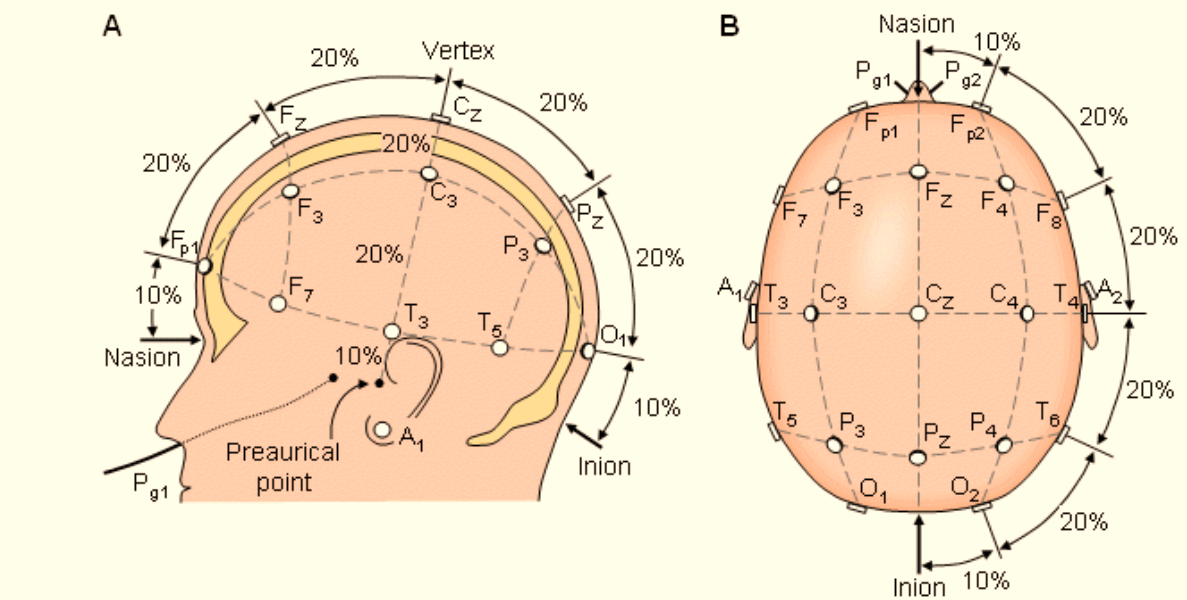


---

Ploteo de todos los registros representativos del paciente selecionado, marcando el inicio y final del episodio. Se ploteara los 18 canales seleccionados.

---


Graficando Seizure 1 en archivo PN00-1.edf


C:\Users\Usuario\AppData\Local\Temp\ipykernel_3148\1699546407.py:112: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_3148\1699546407.py:112: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_3148\1699546407.py:112: RuntimeWarning: Highpass cutoff frequency 15.91549 is greater than lowpass cutoff frequency 15.0, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


Frecuencia de muestreo: 512.0 Hz
Canales usados: ['EEG T3', 'EEG T4', 'EEG T5', 'EEG T6', 'EEG Fp1', 'EEG Fp2', 'EEG F3', 'EEG F4', 'EEG F7', 'EEG F8', 'EEG C3', 'EEG C4', 'EEG Cz', 'EEG P3', 'EEG P4', 'EEG Pz', 'EEG O1', 'EEG O2']


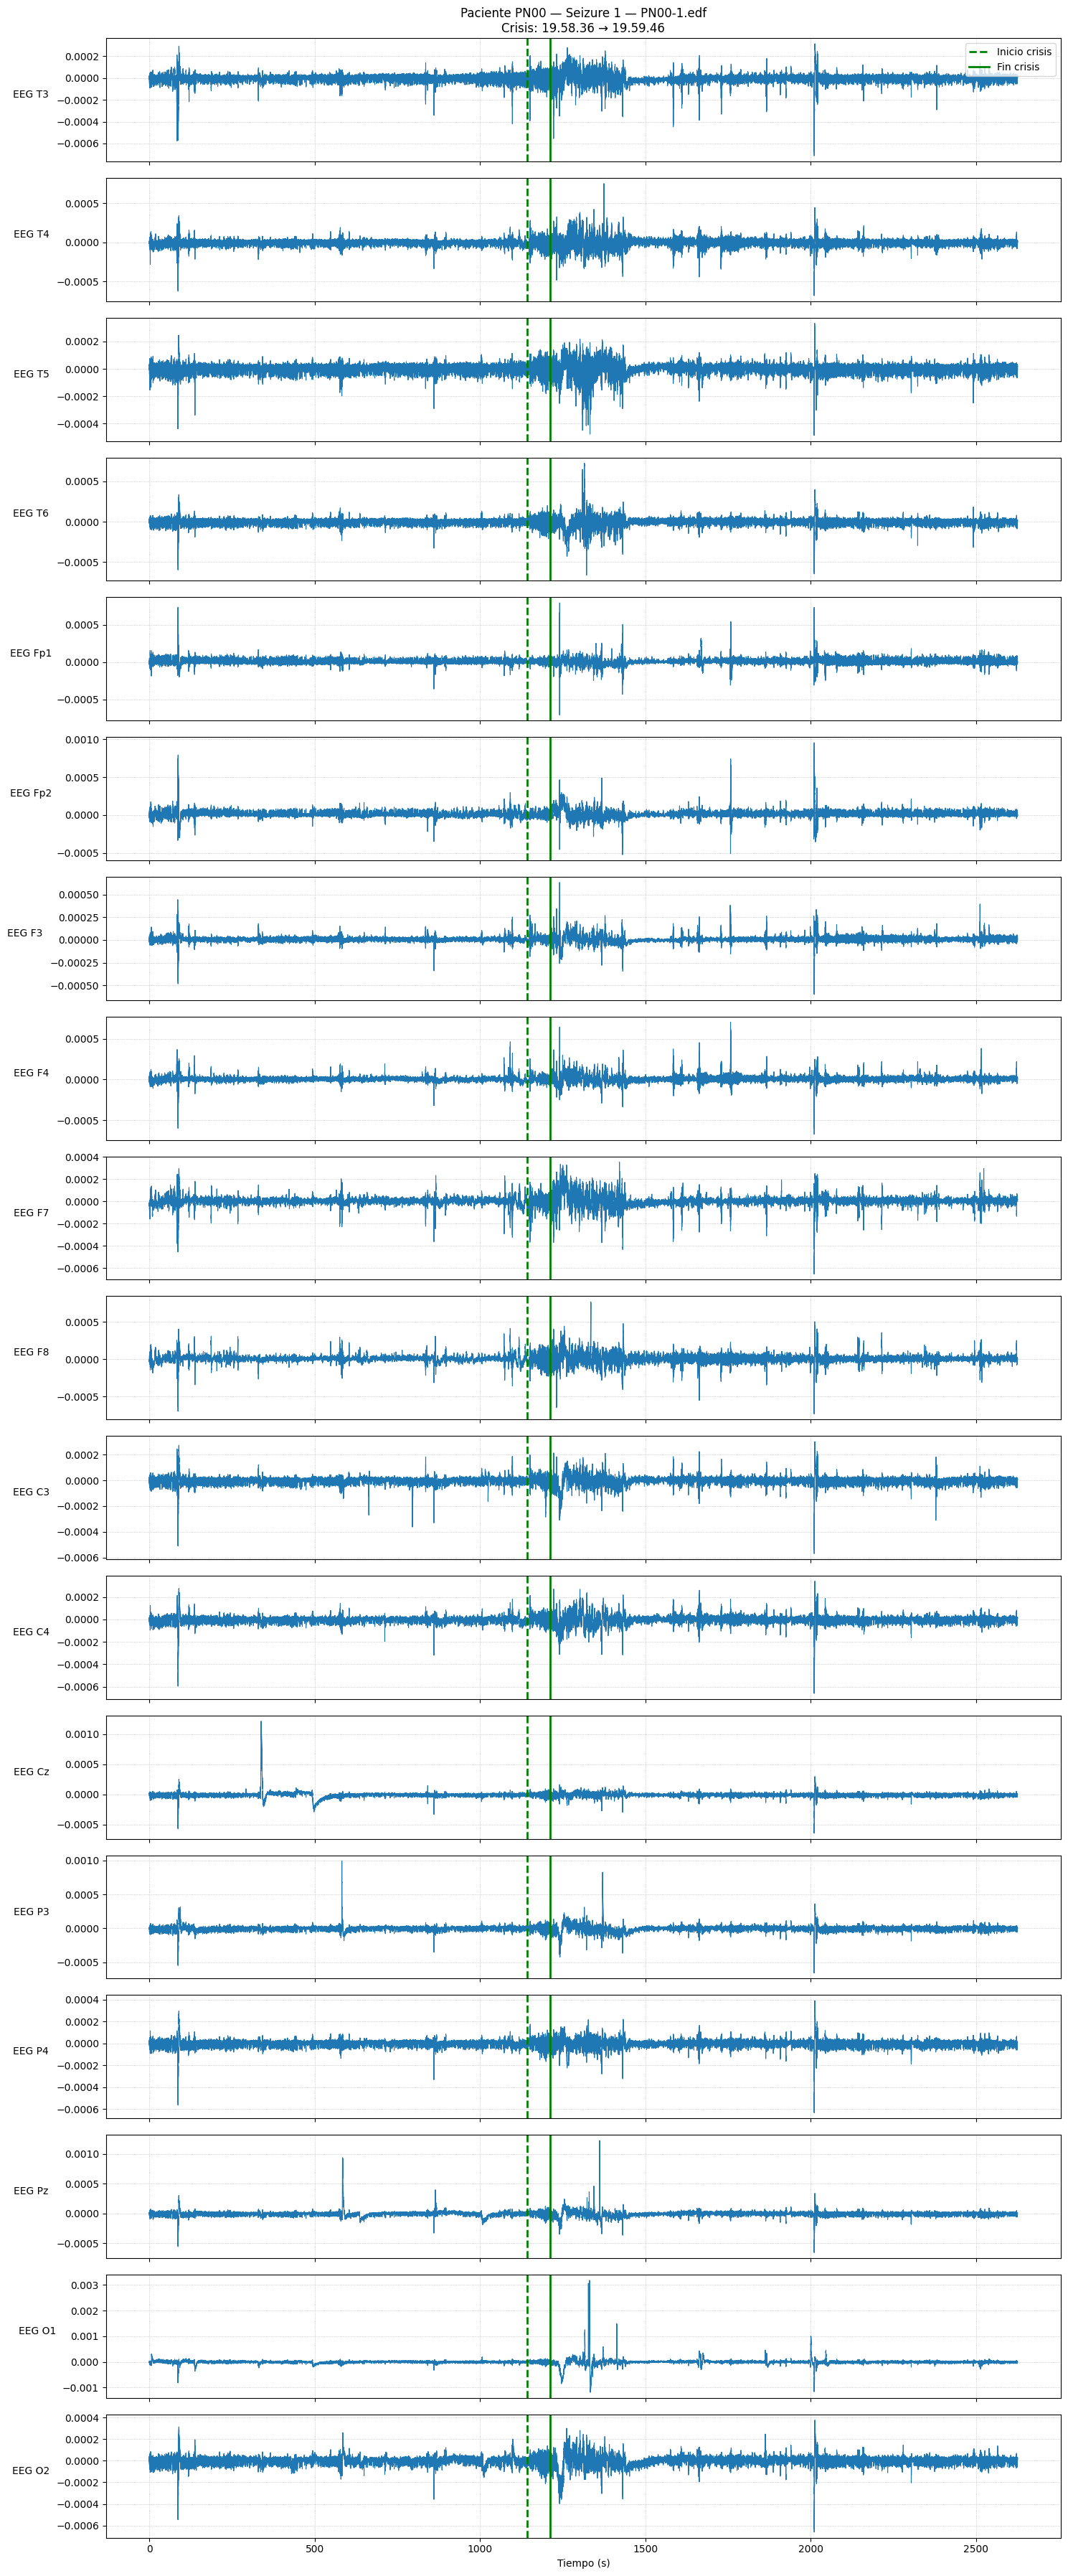


Graficando Seizure 2 en archivo PN00-2.edf


C:\Users\Usuario\AppData\Local\Temp\ipykernel_3148\1699546407.py:112: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_3148\1699546407.py:112: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_3148\1699546407.py:112: RuntimeWarning: Highpass cutoff frequency 15.91549 is greater than lowpass cutoff frequency 15.0, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


Frecuencia de muestreo: 512.0 Hz
Canales usados: ['EEG T3', 'EEG T4', 'EEG T5', 'EEG T6', 'EEG Fp1', 'EEG Fp2', 'EEG F3', 'EEG F4', 'EEG F7', 'EEG F8', 'EEG C3', 'EEG C4', 'EEG Cz', 'EEG P3', 'EEG P4', 'EEG Pz', 'EEG O1', 'EEG O2']


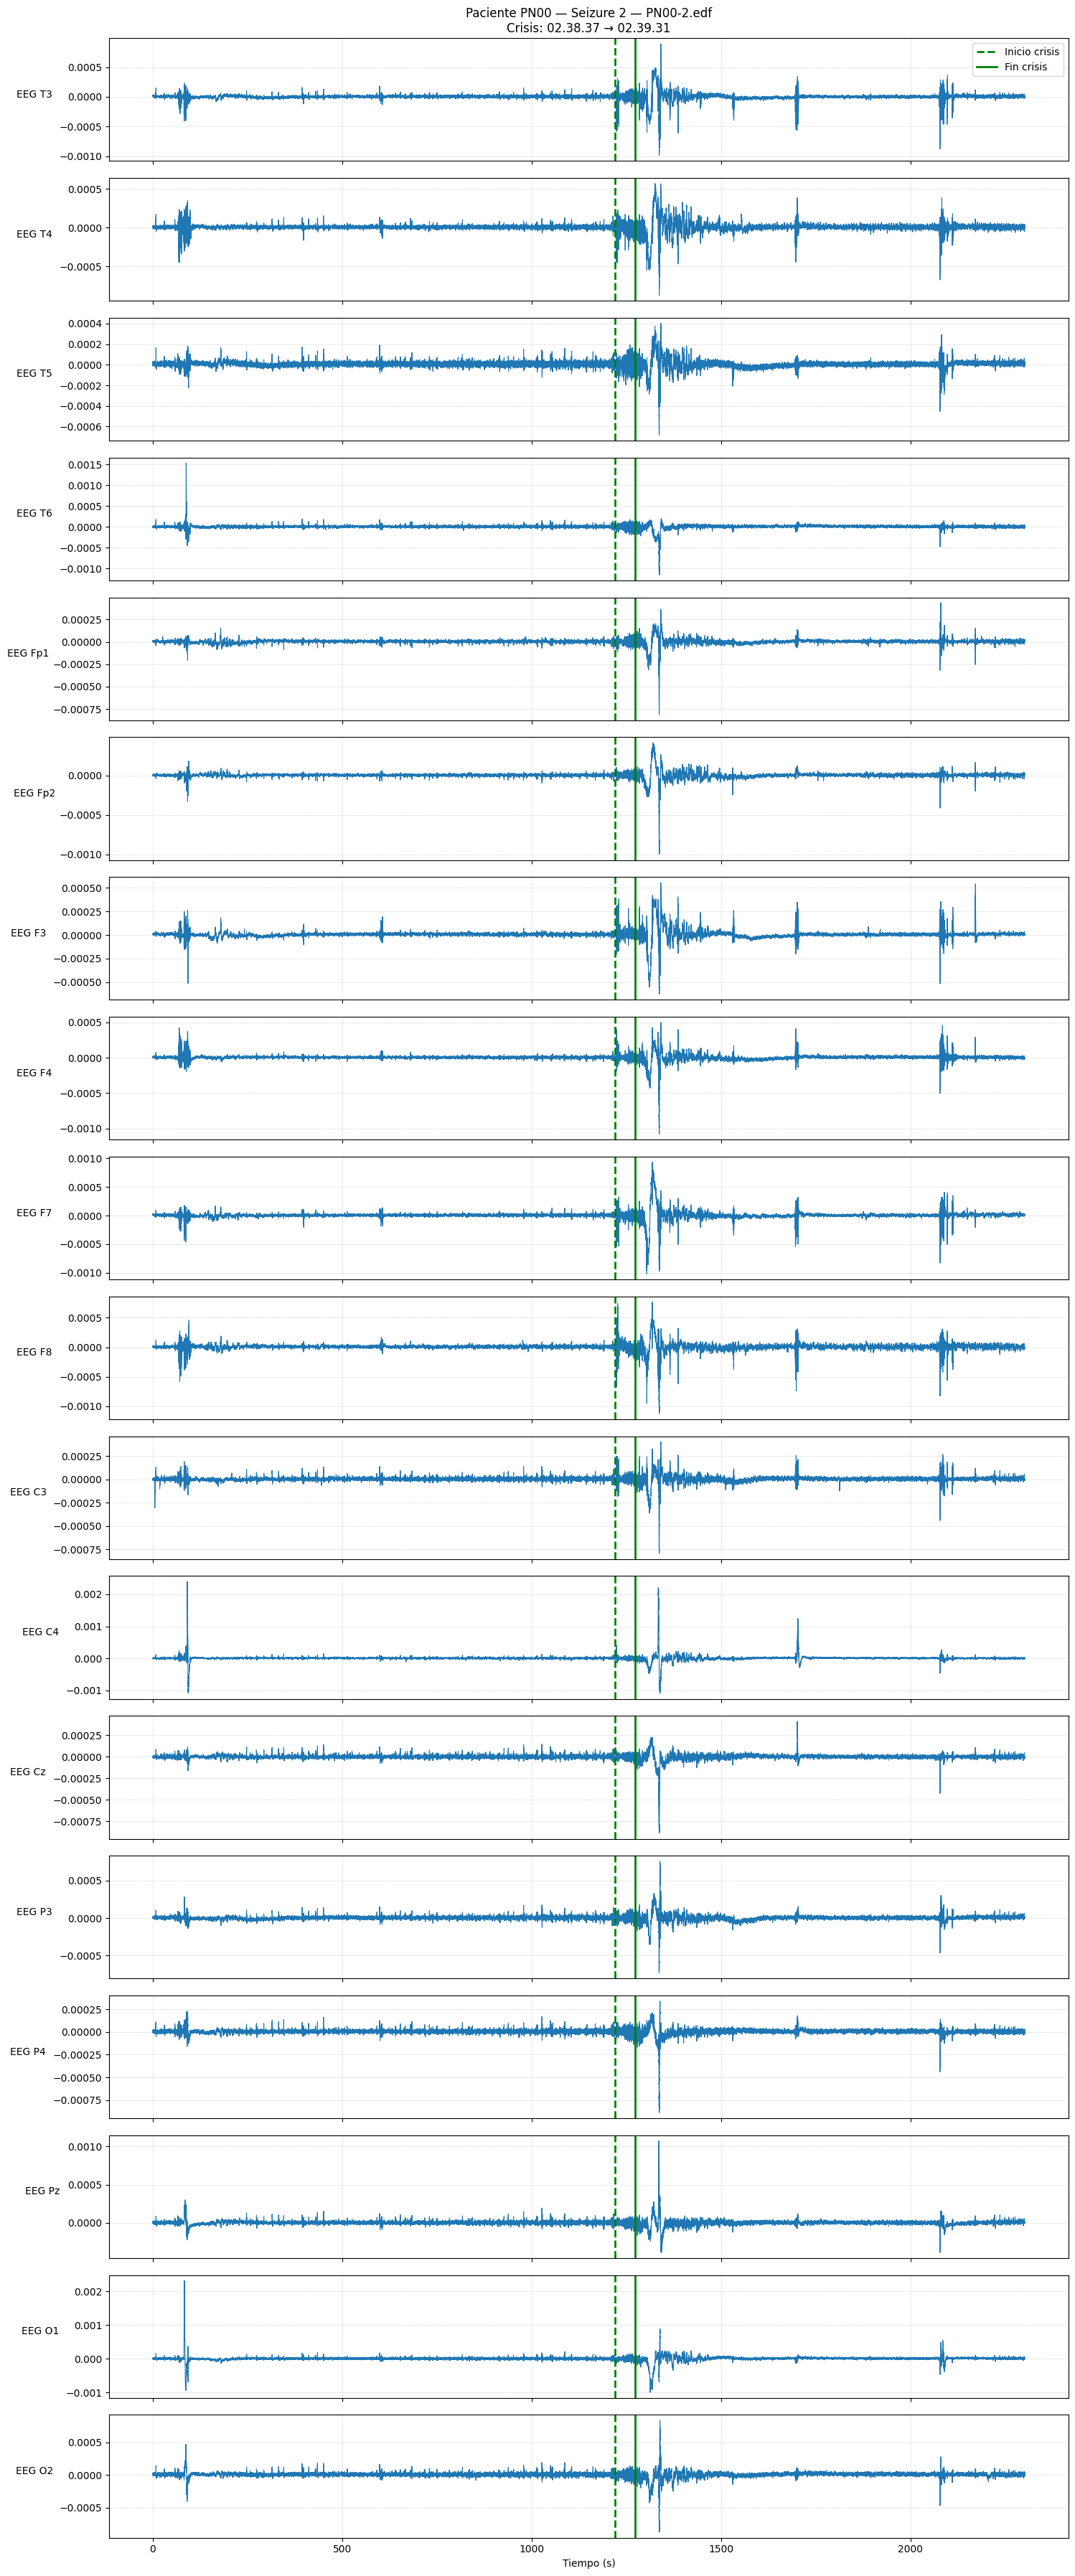


Graficando Seizure 3 en archivo PN00-3.edf


C:\Users\Usuario\AppData\Local\Temp\ipykernel_3148\1699546407.py:112: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_3148\1699546407.py:112: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_3148\1699546407.py:112: RuntimeWarning: Highpass cutoff frequency 15.91549 is greater than lowpass cutoff frequency 15.0, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


Frecuencia de muestreo: 512.0 Hz
Canales usados: ['EEG T3', 'EEG T4', 'EEG T5', 'EEG T6', 'EEG Fp1', 'EEG Fp2', 'EEG F3', 'EEG F4', 'EEG F7', 'EEG F8', 'EEG C3', 'EEG C4', 'EEG Cz', 'EEG P3', 'EEG P4', 'EEG Pz', 'EEG O1', 'EEG O2']


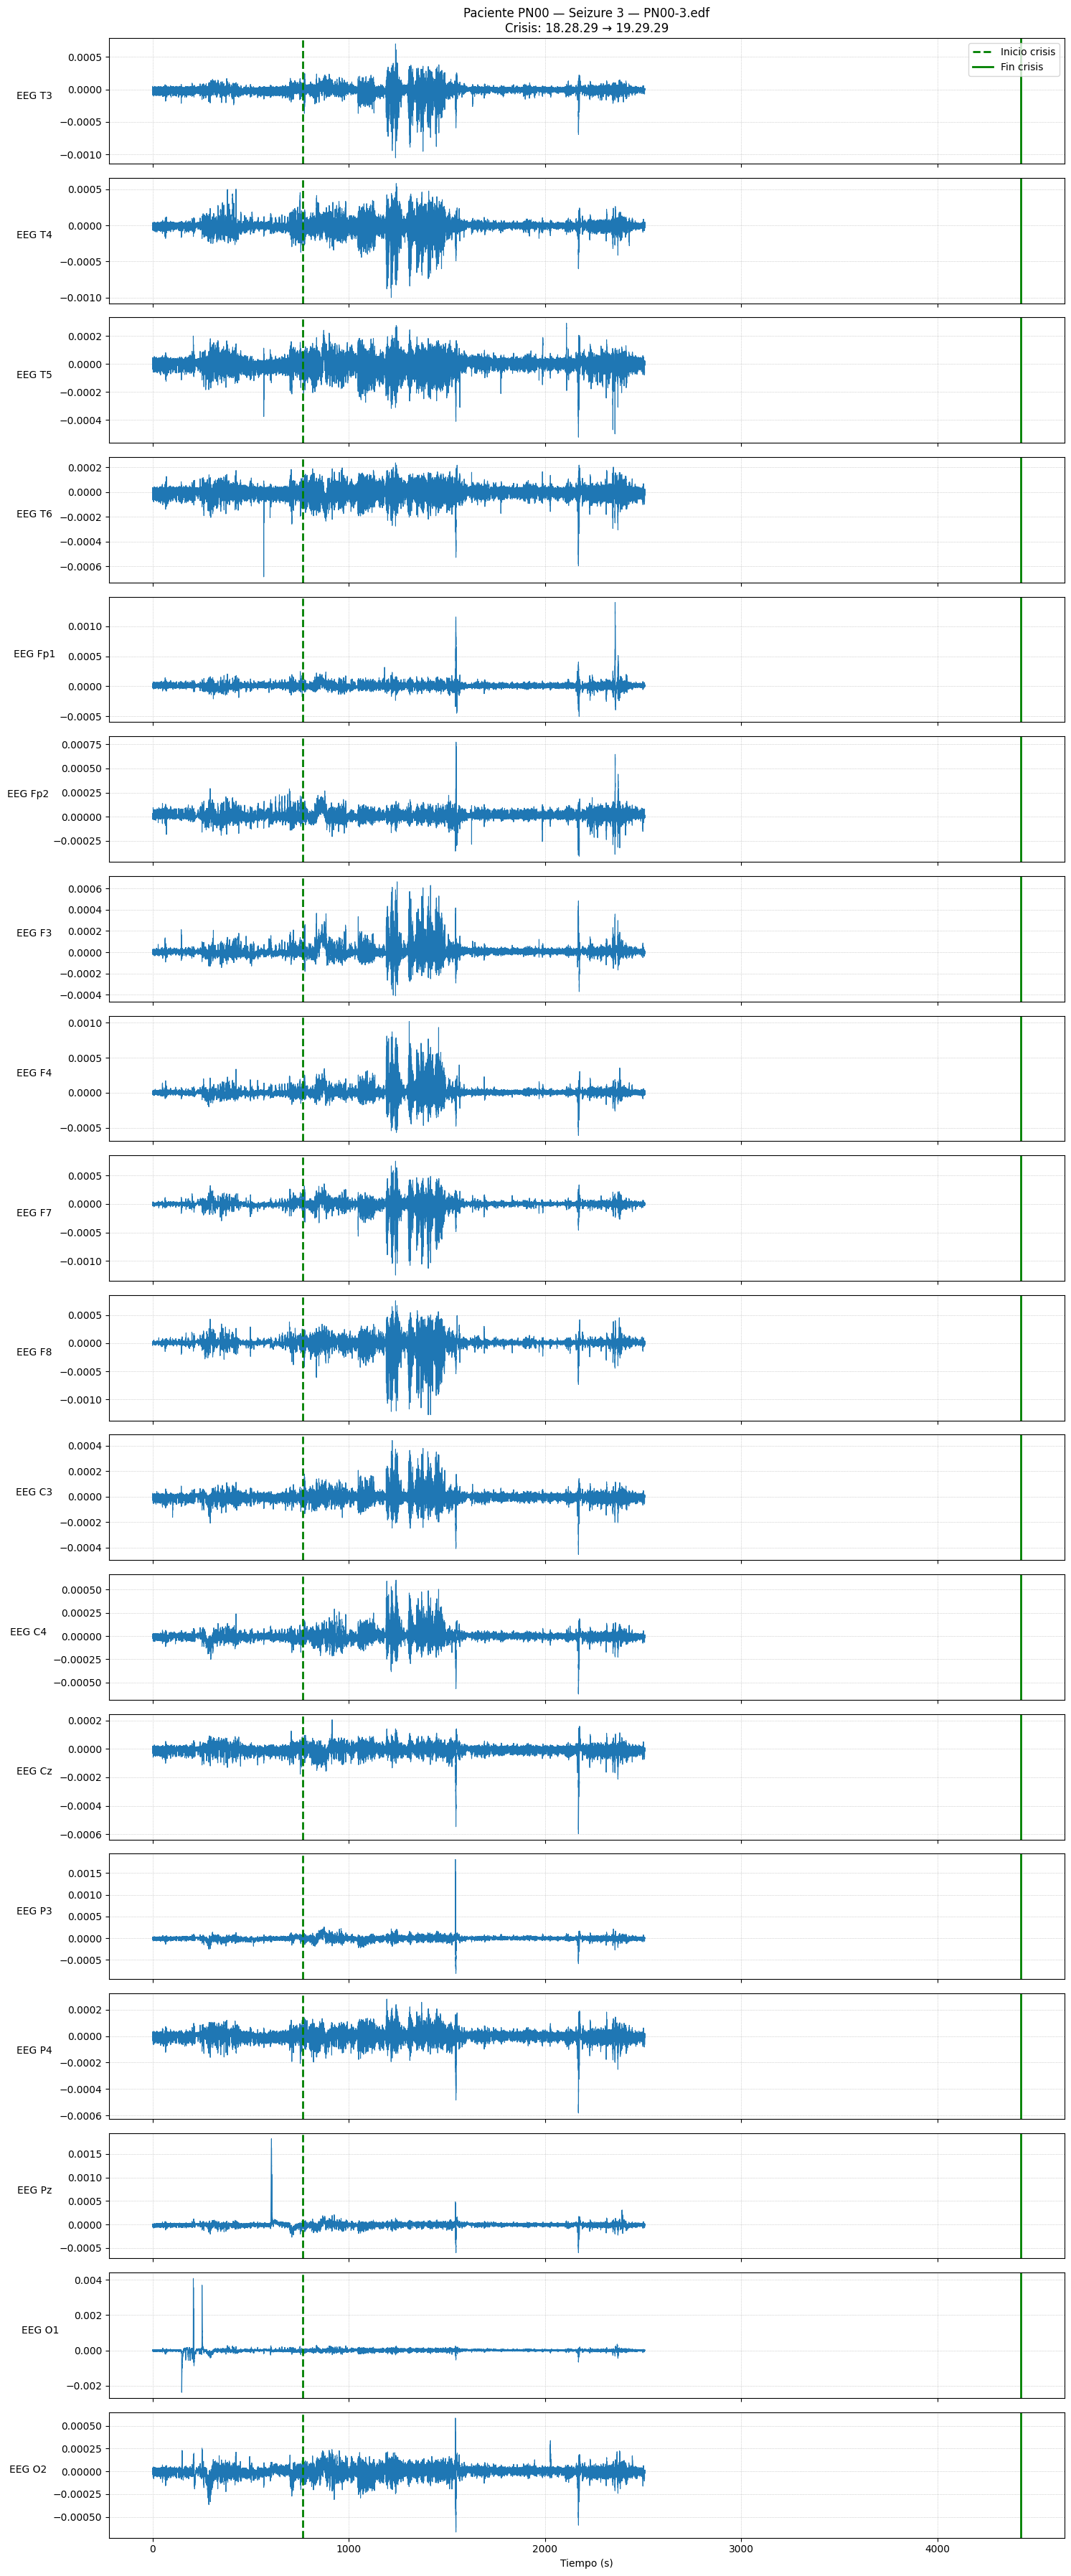


Graficando Seizure 4 en archivo PN00-4.edf


C:\Users\Usuario\AppData\Local\Temp\ipykernel_3148\1699546407.py:112: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_3148\1699546407.py:112: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_3148\1699546407.py:112: RuntimeWarning: Highpass cutoff frequency 15.91549 is greater than lowpass cutoff frequency 15.0, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


Frecuencia de muestreo: 512.0 Hz
Canales usados: ['EEG T3', 'EEG T4', 'EEG T5', 'EEG T6', 'EEG Fp1', 'EEG Fp2', 'EEG F3', 'EEG F4', 'EEG F7', 'EEG F8', 'EEG C3', 'EEG C4', 'EEG Cz', 'EEG P3', 'EEG P4', 'EEG Pz', 'EEG O1', 'EEG O2']


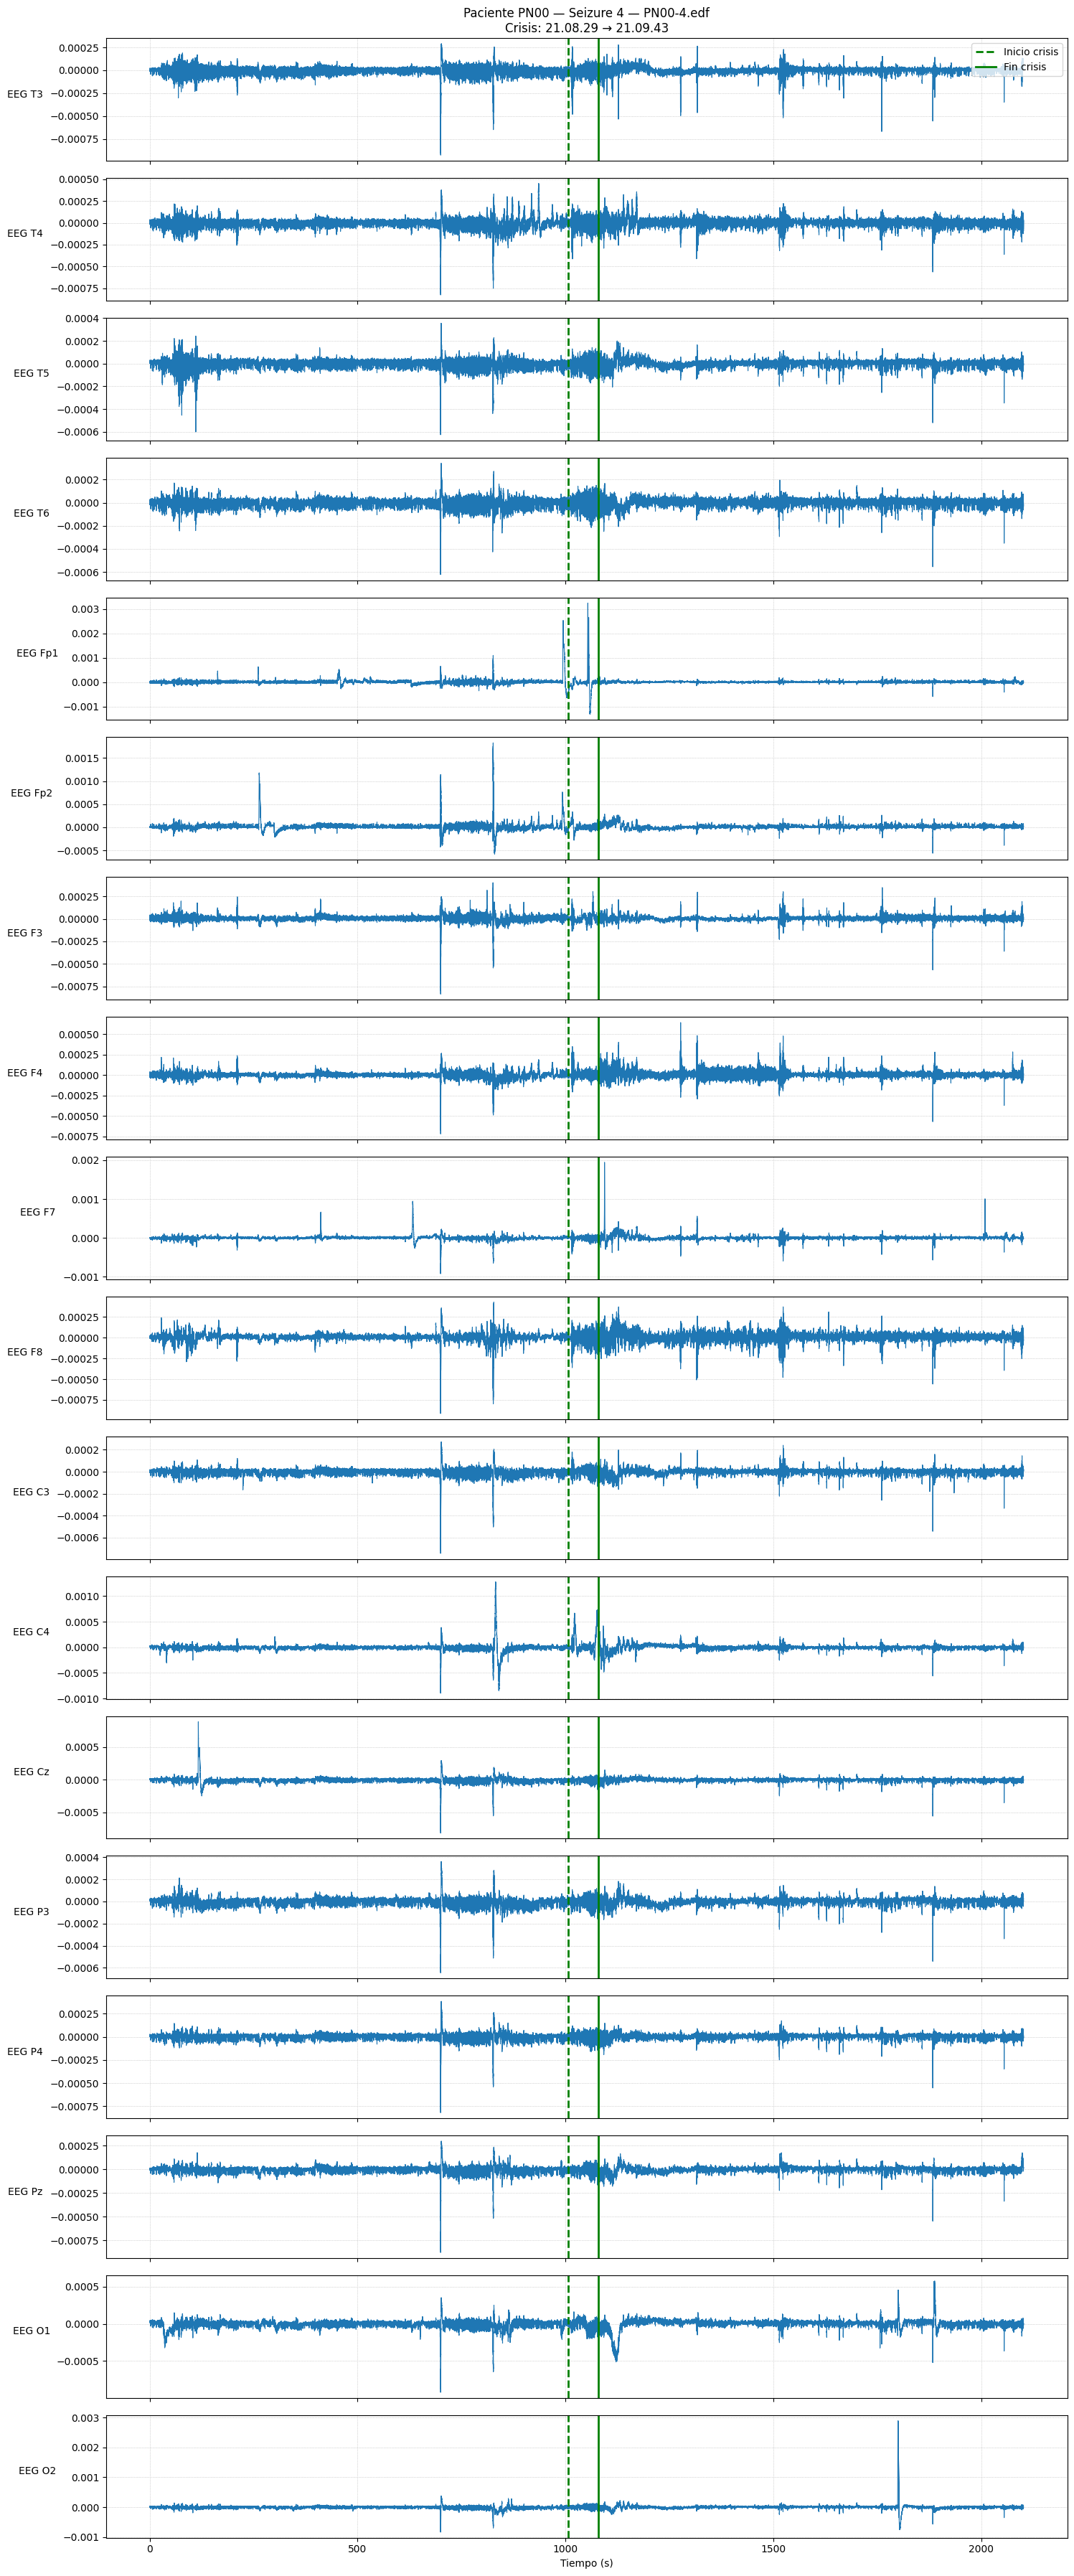


Graficando Seizure 5 en archivo PN00-5.edf


C:\Users\Usuario\AppData\Local\Temp\ipykernel_3148\1699546407.py:112: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_3148\1699546407.py:112: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_3148\1699546407.py:112: RuntimeWarning: Highpass cutoff frequency 15.91549 is greater than lowpass cutoff frequency 15.0, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


Frecuencia de muestreo: 512.0 Hz
Canales usados: ['EEG T3', 'EEG T4', 'EEG T5', 'EEG T6', 'EEG Fp1', 'EEG Fp2', 'EEG F3', 'EEG F4', 'EEG F7', 'EEG F8', 'EEG C3', 'EEG C4', 'EEG Cz', 'EEG P3', 'EEG P4', 'EEG Pz', 'EEG O1', 'EEG O2']


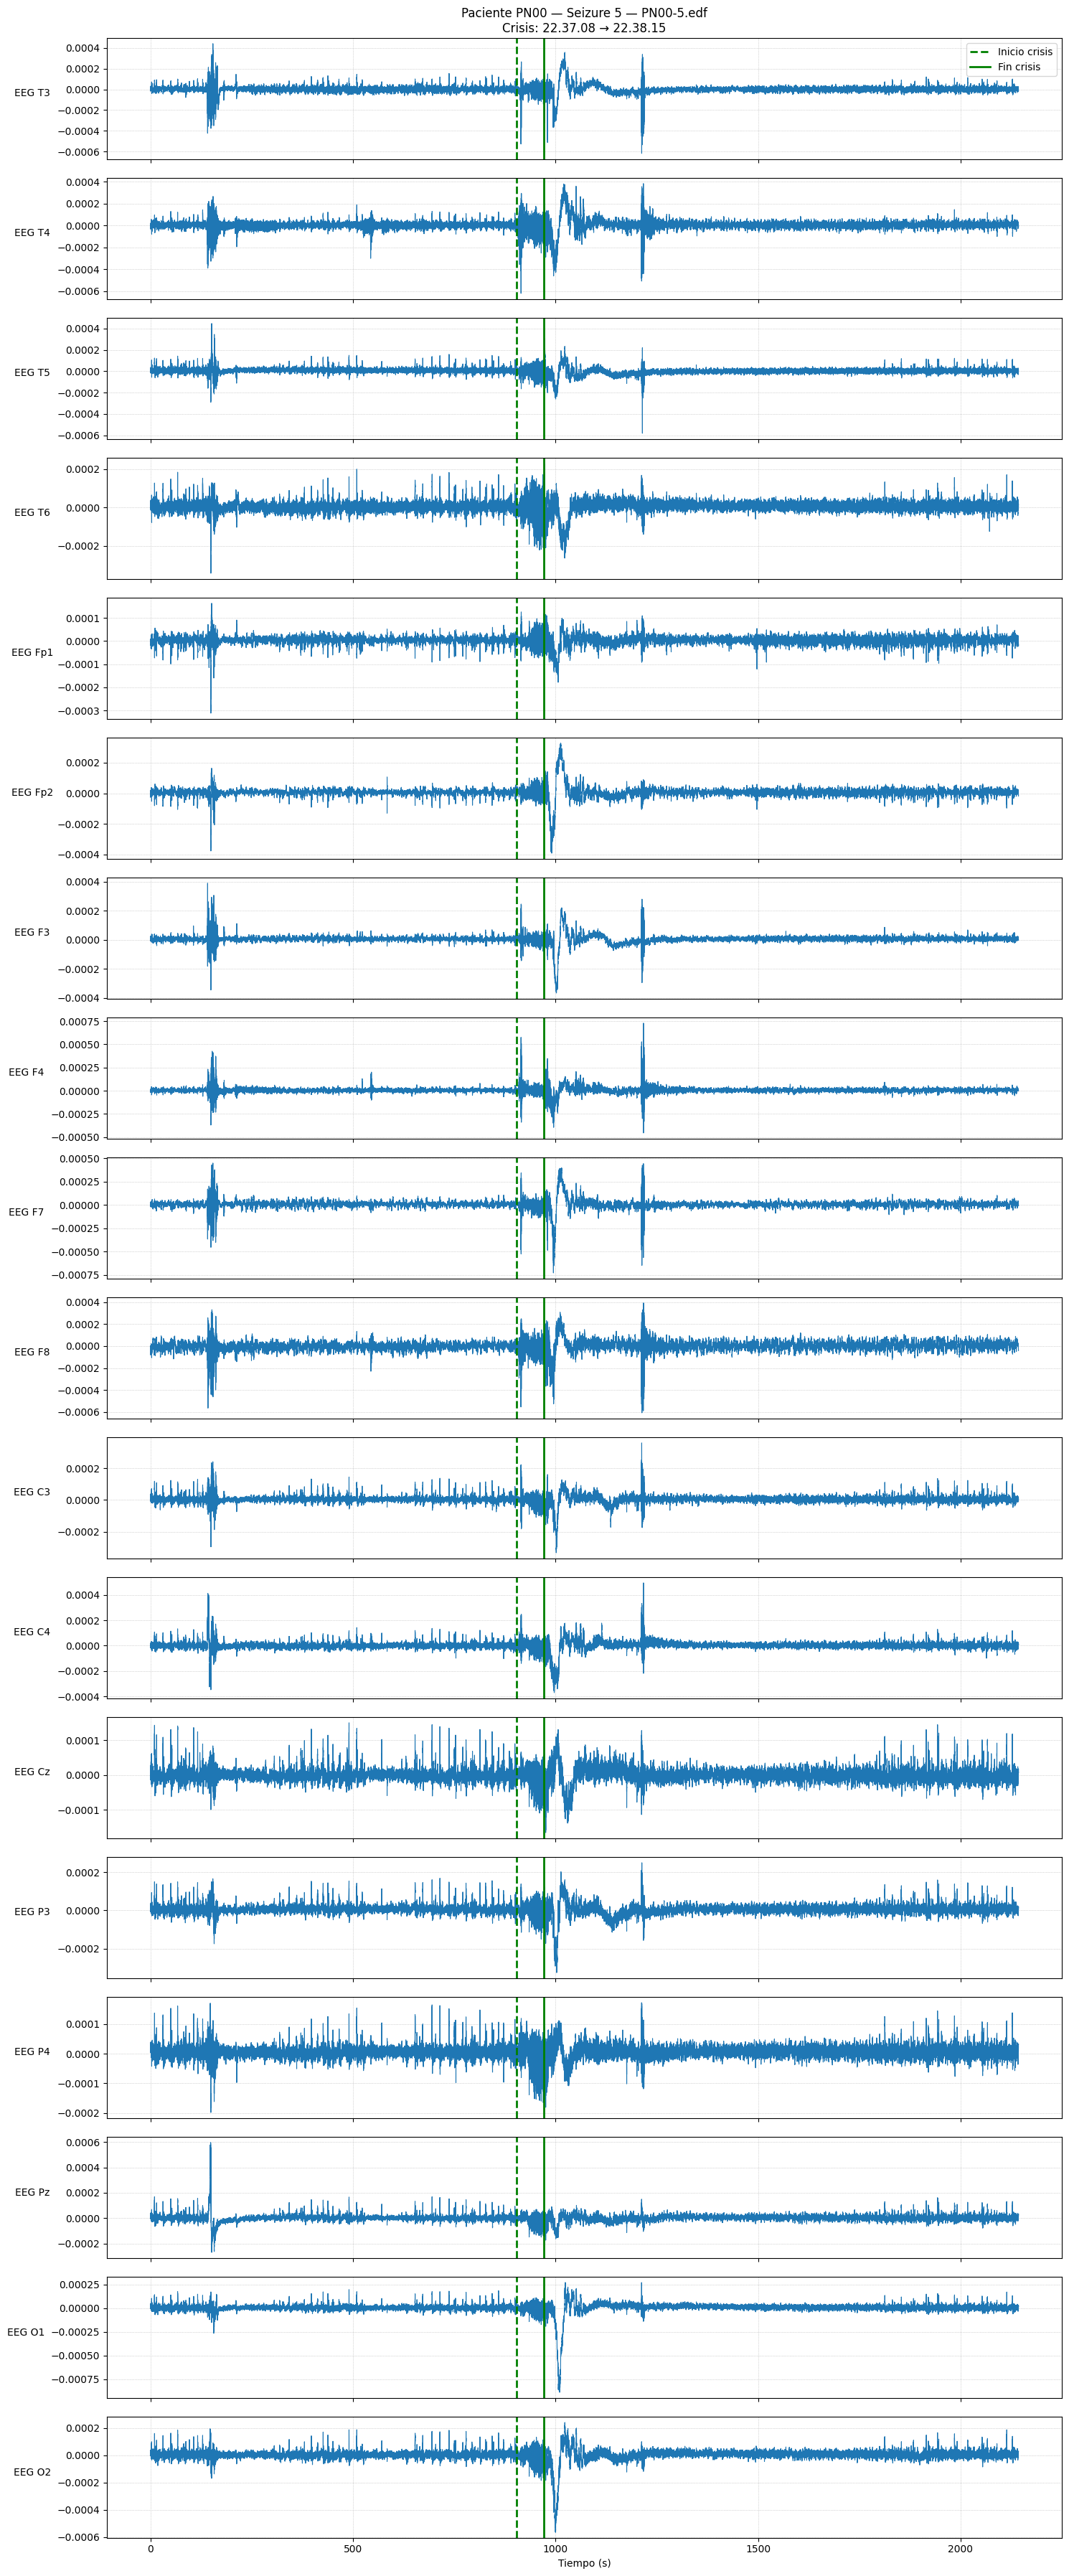

In [12]:
# ============================================================
# IMPORTS
# ============================================================
import os
import re
import mne
import numpy as np
import matplotlib.pyplot as plt

# Para que los gráficos se vean dentro del notebook
%matplotlib inline


# ============================================================
# RUTAS
# ============================================================
#base_path = r"D:\CICLO 2025-2 UNI\PROGRAMACION_PARALELA\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00"
base_path = r"D:\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00"
txt_path = os.path.join(base_path, "Seizures-list-PN00.txt")


# ============================================================
# FUNCIONES AUXILIARES
# ============================================================
def parse_time_hms_with_dots(t):
    """
    Convierte un tiempo HH.MM.SS a segundos absolutos
    """
    t = t.strip()
    h, m, s = t.split(".")
    return int(h) * 3600 + int(m) * 60 + int(s)


# ============================================================
# LEER ARCHIVO DE CRISIS
# ============================================================
seizures = []
current = None

with open(txt_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue

        if line.startswith("Seizure n"):
            if current is not None:
                seizures.append(current)
            m = re.search(r"Seizure n\s+(\d+)", line)
            current = {"n": int(m.group(1))}

        elif line.startswith("File name:"):
            current["file_name"] = line.split(":")[1].strip()

        elif line.startswith("Registration start time"):
            current["reg_start"] = line.split(":")[1].strip()

        elif line.startswith("Registration end time"):
            current["reg_end"] = line.split(":")[1].strip()

        elif line.startswith("Seizure start time"):
            current["seiz_start"] = line.split(":")[1].strip()

        elif line.startswith("Seizure end time"):
            current["seiz_end"] = line.split(":")[1].strip()

if current is not None:
    seizures.append(current)


# ============================================================
# CANALES REPRESENTATIVOS (18 CANALES)
# ============================================================
REP_CHANNELS = [
    # Temporales
    "EEG T3", "EEG T4", "EEG T5", "EEG T6",

    # Frontales
    "EEG Fp1", "EEG Fp2", "EEG F3", "EEG F4", "EEG F7", "EEG F8",

    # Centrales
    "EEG C3", "EEG C4", "EEG Cz",

    # Parietales
    "EEG P3", "EEG P4", "EEG Pz",

    # Occipitales
    "EEG O1", "EEG O2"
]


# ============================================================
# FUNCIÓN DE GRAFICADO
# ============================================================
def plot_full_record_with_markers(entry, base_path=base_path, rep_channels=REP_CHANNELS):

    file_name = entry["file_name"]
    edf_path = os.path.join(base_path, file_name)

    print(f"\nGraficando Seizure {entry['n']} en archivo {file_name}")

    # Tiempos absolutos en segundos
    reg_start  = parse_time_hms_with_dots(entry["reg_start"])
    seiz_start = parse_time_hms_with_dots(entry["seiz_start"])
    seiz_end   = parse_time_hms_with_dots(entry["seiz_end"])

    # Tiempos relativos dentro del EDF
    rel_start = seiz_start - reg_start
    rel_end   = seiz_end   - reg_start

    # Cargar EDF
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    sfreq = raw.info["sfreq"]

    print("Frecuencia de muestreo:", sfreq, "Hz")

    # Seleccionar solo canales disponibles
    available = [ch for ch in rep_channels if ch in raw.ch_names]
    raw_sel = raw.copy().pick(available)

    print("Canales usados:", available)

    # Extraer datos completos
    data, times = raw_sel.get_data(return_times=True)
    n_ch = len(available)

    # --------------------------------------------------------
    # GRAFICADO
    # --------------------------------------------------------
    fig, axes = plt.subplots(n_ch, 1, figsize=(15, 2 * n_ch), sharex=True)

    if n_ch == 1:
        axes = [axes]

    for i, ch in enumerate(available):
        ax = axes[i]
        ax.plot(times, data[i], linewidth=0.8)

        # Líneas de crisis
        ax.axvline(rel_start, color="green", linestyle="--",
                   linewidth=2, label="Inicio crisis" if i == 0 else None)
        ax.axvline(rel_end, color="green", linestyle="-",
                   linewidth=2, label="Fin crisis" if i == 0 else None)

        ax.set_ylabel(ch, rotation=0, labelpad=25)
        ax.grid(True, linestyle=":", linewidth=0.5)

        if i == 0:
            ax.set_title(
                f"Paciente PN00 — Seizure {entry['n']} — {file_name}\n"
                f"Crisis: {entry['seiz_start']} → {entry['seiz_end']}"
            )

    axes[-1].set_xlabel("Tiempo (s)")
    axes[0].legend(loc="upper right")
    plt.tight_layout()
    plt.show()


# ============================================================
# EJECUTAR PARA CADA CRISIS
# ============================================================
for entry in seizures:
    plot_full_record_with_markers(entry)


## [9] LIMPIEZA DE CANALES A USAR

Selecionamos los canales representativos, para ello primero vemos que canales tiene la data, luego hacemos la limpieza

In [13]:
# para visualizar los canales de la data inicial
import mne
import os

#edf_path = r"D:\CICLO 2025-2 UNI\PROGRAMACION_PARALELA\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00\PN00-1.edf"
edf_path = r"D:\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00\PN00-1.edf"

raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)

print("Número de canales:", len(raw.ch_names))
print("Canales:")
for i, ch in enumerate(raw.ch_names):
    print(f"{i:02d}: {ch}")


Número de canales: 35
Canales:
00: EEG Fp1
01: EEG F3
02: EEG C3
03: EEG P3
04: EEG O1
05: EEG F7
06: EEG T3
07: EEG T5
08: EEG Fc1
09: EEG Fc5
10: EEG Cp1
11: EEG Cp5
12: EEG F9
13: EEG Fz
14: EEG Cz
15: EEG Pz
16: EEG Fp2
17: EEG F4
18: EEG C4
19: EEG P4
20: EEG O2
21: EEG F8
22: EEG T4
23: EEG T6
24: EEG Fc2
25: EEG Fc6
26: EEG Cp2
27: EEG Cp6
28: EEG F10
29: EKG EKG
30: SPO2
31: HR
32: 1
33: 2
34: MK


C:\Users\Usuario\AppData\Local\Temp\ipykernel_3148\2661383326.py:8: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_3148\2661383326.py:8: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_3148\2661383326.py:8: RuntimeWarning: Highpass cutoff frequency 15.91549 is greater than lowpass cutoff frequency 15.0, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)


In [15]:
# para modificar la data a los canales que requerimos

import mne
import os
import numpy as np

# RUTA DE LOS ARCHIVOS EDF
#edf_dir = r"D:\CICLO 2025-2 UNI\PROGRAMACION_PARALELA\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00"
edf_dir =r"D:\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00"

# CANALES REPRESENTATIVOS (18 CANALES EEG CONFIRMADOS)
REP_CHANNELS = [
    "T3", "T4", "T5", "T6",
    "Fp1", "Fp2", "F3", "F4", "F7", "F8",
    "C3", "C4", "Cz",
    "P3", "P4", "Pz",
    "O1", "O2"
]


# FUNCIÓN AUXILIAR: NOMBRE BASE DEL CANAL
def base_name(ch):
    # Convierte "EEG Fp1" -> "Fp1"
    return ch.replace("EEG ", "")


# ---------- ENTRENAMIENTO ----------
train_files = ["PN00-1.edf", "PN00-2.edf"]

raws_train = [
    mne.io.read_raw_edf(
        os.path.join(edf_dir, f),
        preload=True,
        verbose="error"
    )
    for f in train_files
]

raw_train = mne.concatenate_raws(raws_train)

# --- Selección directa por nombre base (forma correcta aquí) ---
available_train = [
    ch for ch in raw_train.ch_names
    if base_name(ch) in REP_CHANNELS
]

# Forzar orden fijo (CRÍTICO para RN)
available_train = [
    f"EEG {ch}" for ch in REP_CHANNELS
    if f"EEG {ch}" in available_train
]

raw_train.pick(available_train)

print("Canales entrenamiento:")
print(raw_train.ch_names)
print("raw_train shape:", raw_train.get_data().shape)
# ==> (18, N_train)


# PRUEBA 
test_files = ["PN00-4.edf"]

raws_test = [
    mne.io.read_raw_edf(
        os.path.join(edf_dir, f),
        preload=True,
        verbose="error"
    )
    for f in test_files
]

raw_test = mne.concatenate_raws(raws_test)

available_test = [
    ch for ch in raw_test.ch_names
    if base_name(ch) in REP_CHANNELS
]

available_test = [
    f"EEG {ch}" for ch in REP_CHANNELS
    if f"EEG {ch}" in available_test
]

raw_test.pick(available_test)

print("\nCanales prueba:")
print(raw_test.ch_names)
print("raw_test shape:", raw_test.get_data().shape)
# ==> (18, N_test)


# REEVALUACION
retest_files = ["PN00-5.edf"]

raws_retest = [
    mne.io.read_raw_edf(
        os.path.join(edf_dir, f),
        preload=True,
        verbose="error"
    )
    for f in retest_files
]

raw_retest = mne.concatenate_raws(raws_retest)

available_retest = [
    ch for ch in raw_retest.ch_names
    if base_name(ch) in REP_CHANNELS
]

available_retest = [
    f"EEG {ch}" for ch in REP_CHANNELS
    if f"EEG {ch}" in available_retest
]

raw_retest.pick(available_retest)

X_retest = raw_retest.get_data()

print("\nCanales reevaluación:")
print(raw_retest.ch_names)
print("raw_retest shape:", X_retest.shape)
# ==> (18, N_retest)


Canales entrenamiento:
['EEG T3', 'EEG T4', 'EEG T5', 'EEG T6', 'EEG Fp1', 'EEG Fp2', 'EEG F3', 'EEG F4', 'EEG F7', 'EEG F8', 'EEG C3', 'EEG C4', 'EEG Cz', 'EEG P3', 'EEG P4', 'EEG Pz', 'EEG O1', 'EEG O2']
raw_train shape: (18, 2522624)

Canales prueba:
['EEG T3', 'EEG T4', 'EEG T5', 'EEG T6', 'EEG Fp1', 'EEG Fp2', 'EEG F3', 'EEG F4', 'EEG F7', 'EEG F8', 'EEG C3', 'EEG C4', 'EEG Cz', 'EEG P3', 'EEG P4', 'EEG Pz', 'EEG O1', 'EEG O2']
raw_test shape: (18, 1076224)

Canales reevaluación:
['EEG T3', 'EEG T4', 'EEG T5', 'EEG T6', 'EEG Fp1', 'EEG Fp2', 'EEG F3', 'EEG F4', 'EEG F7', 'EEG F8', 'EEG C3', 'EEG C4', 'EEG Cz', 'EEG P3', 'EEG P4', 'EEG Pz', 'EEG O1', 'EEG O2']
raw_retest shape: (18, 1097216)


In [18]:
# ============================================================
# VARIABLES (COHERENTES CON PN00 Y raw_train / raw_test)
# ============================================================

import numpy as np

# ------------------------------------------------------------
# FRECUENCIA DE MUESTREO
# ------------------------------------------------------------
sfreq = int(raw_train.info["sfreq"])     # 512 Hz


# ------------------------------------------------------------
# DATA DE ENTRENAMIENTO
# ------------------------------------------------------------
datatrain = raw_train.get_data()         # shape = (18, N_samples_train)
n_samples_train = datatrain.shape[1]
Ntrain = n_samples_train // sfreq        # duración total (s)


# ------------------------------------------------------------
# DATA DE PRUEBA
# ------------------------------------------------------------
datatest = raw_test.get_data()            # shape = (18, N_samples_test)
n_samples_test = datatest.shape[1]
Ntest = n_samples_test // sfreq


# ------------------------------------------------------------
# INFORMACIÓN DE FILTRADO
# ------------------------------------------------------------
lowpass = raw_train.info["lowpass"]


# ------------------------------------------------------------
# CANALES
# ------------------------------------------------------------
ch_names = raw_train.ch_names
n_chan = len(ch_names)                    # DEBE ser 18


# ------------------------------------------------------------
# ÍNDICES DE CANALES (ORDEN REAL Y FIJO)
# ------------------------------------------------------------
T3, T4, T5, T6, \
Fp1, Fp2, F3, F4, F7, F8, \
C3, C4, Cz, \
P3, P4, Pz, \
O1, O2 = range(18)


# ============================================================
# EVENTOS DE CRISIS (TIEMPOS REALES, PN00-1 y PN00-2)
# ============================================================

# --- PN00-1.edf ---
# Inicio registro : 19:39:33
# Inicio crisis   : 19:58:36  -> 1143 s
# Fin crisis      : 19:59:46  -> 1213 s
seizure1_start = 1143
seizure1_end   = 1213


# --- PN00-2.edf ---
# Inicio registro : 02:18:17
# Inicio crisis   : 02:38:37  -> 1220 s
# Fin crisis      : 02:39:31  -> 1274 s

# Duración PN00-1 en segundos (para corrimiento)
print(raws_train[0].n_times // sfreq)
dur_PN00_1_sec = raws_train[0].n_times // sfreq

seizure2_start = dur_PN00_1_sec + 1220
seizure2_end   = dur_PN00_1_sec + 1274


# ------------------------------------------------------------
# VECTORES DE EVENTOS (INICIO DE CRISIS)
# ------------------------------------------------------------
secondeventscrisis = np.array([
    seizure1_start,
    seizure2_start
])


# ------------------------------------------------------------
# EVENTOS DE CRISIS EN TEST (PN00-4)
# ------------------------------------------------------------
# Inicio registro : 20:51:43
# Inicio crisis   : 21:08:29 -> 1006 s
# Fin crisis      : 21:09:43 -> 1080 s

secondeventscrisistest = np.array([1006])


4927


In [20]:
n_time_samps = raw_train.n_times
time_secs = raw_train.times
ch_names = raw_train.ch_names
n_chan = len(ch_names)  # note: there is no raw.n_channels attribute
print(
    f"the (cropped) sample data object has {n_time_samps} time samples and "
    f"{n_chan} channels."
)
print(f"The last time sample is at {time_secs[-1]} seconds.")
print("The first few channel names are {}.".format(", ".join(ch_names[:3])))
print()  # insert a blank line in the output

# some examples of raw.info:
print("bad channels:", raw_train.info["bads"])  # chs marked "bad" during acquisition
print(raw_train.info["sfreq"], "Hz")  # sampling frequency
print(raw_train.info["description"], "\n")  # miscellaneous acquisition info

print(raw_train.info)

the (cropped) sample data object has 2522624 time samples and 18 channels.
The last time sample is at 4926.998046875 seconds.
The first few channel names are EEG T3, EEG T4, EEG T5.

bad channels: []
512.0 Hz
None 

<Info | 8 non-empty values
 bads: []
 ch_names: EEG T3, EEG T4, EEG T5, EEG T6, EEG Fp1, EEG Fp2, EEG F3, EEG ...
 chs: 18 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 256.0 Hz
 meas_date: 2016-01-01 19:39:33 UTC
 nchan: 18
 projs: []
 sfreq: 512.0 Hz
 subject_info: <subject_info | his_id: >
>


In [21]:
# INFO FINAL DE LA DATA CORREGIDA
raw_train.info

<Info | 8 non-empty values
 bads: []
 ch_names: EEG T3, EEG T4, EEG T5, EEG T6, EEG Fp1, EEG Fp2, EEG F3, EEG ...
 chs: 18 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 256.0 Hz
 meas_date: 2016-01-01 19:39:33 UTC
 nchan: 18
 projs: []
 sfreq: 512.0 Hz
 subject_info: <subject_info | his_id: >
>

In [22]:
import numpy as np

def patterndandtarget(F, S, tp, sfreq, ad_1=0, ad_2=0, N=None):
    """
    Genera ventanas EEG (segmentos de 1 segundo) y asigna clases:
      0 -> normal
      1 -> ictal (durante la crisis)
      2 -> preictal (tp segundos antes del inicio de crisis)

    Parámetros
    ----------
    F : np.ndarray
        Señal EEG. Puede ser:
          - shape (n_samples, n_chan)  (recomendado)
          - shape (n_chan, n_samples)  (también soportado)
    S : list / np.ndarray
        Crisis como:
          - [start1, end1, start2, end2, ...]  (segundos relativos)
          - [(start1,end1), (start2,end2), ...]
    tp : int
        Cuántos segundos ANTES de cada inicio se etiquetan como preictal (clase 2).
    sfreq : int
        Frecuencia de muestreo (ej. 512).
    ad_1 : int
        Aumento (oversampling) de clase 1: duplica ad_1 veces cada ventana ictal.
    ad_2 : int
        Aumento (oversampling) de clase 2: duplica ad_2 veces cada ventana preictal.
    N : int | None
        Número de segmentos (segundos) a generar. Si None, se calcula desde F.

    Retorna
    -------
    X : np.ndarray
        Ventanas de 1 segundo.
    y : np.ndarray
        Etiquetas por ventana.
    """

    # ----------------------------
    # Normalizar forma de F a (n_samples, n_chan)
    # ----------------------------
    F = np.asarray(F)
    if F.ndim == 1:
        # Caso 1D: (n_samples,) -> lo tratamos como 1 canal
        F = F[:, None]
    elif F.shape[0] < F.shape[1] and F.shape[0] <= 64:
        # Heurística común: si F es (n_chan, n_samples), lo transponemos
        # (esto evita errores si te llega en formato MNE: (n_chan, n_samples))
        # OJO: si ya está en (n_samples, n_chan), no se transpone.
        # Para tu caso, raw.get_data() da (n_chan, n_samples), así que esto ayuda.
        F = F.T

    n_samples = F.shape[0]

    # ----------------------------
    # Número de segmentos (1 segundo)
    # ----------------------------
    if N is None:
        N = n_samples // sfreq  # segundos completos

    # ----------------------------
    # Parsear S a lista de intervalos [(start,end), ...]
    # ----------------------------
    S = np.asarray(S, dtype=int)

    intervals = []
    if S.ndim == 2 and S.shape[1] == 2:
        # [(start,end), ...]
        intervals = [(int(a), int(b)) for a, b in S]
    else:
        # [start1,end1,start2,end2,...]
        if len(S) % 2 != 0:
            raise ValueError("S debe tener longitud par: [start1,end1,start2,end2,...]")
        for i in range(0, len(S), 2):
            a = int(S[i]); b = int(S[i+1])
            intervals.append((a, b))

    # Validar/normalizar intervalos (por si vienen desordenados)
    intervals = [(min(a, b), max(a, b)) for a, b in intervals]

    # ----------------------------
    # Conjuntos de segundos ictales y preictales
    # ----------------------------
    ictal_secs = set()
    preictal_secs = set()

    for (start, end) in intervals:
        # Ictal: incluye TODO el intervalo [start, end]
        for t in range(max(0, start), max(0, end) + 1):
            ictal_secs.add(t)

        # Preictal: tp segundos antes del inicio: start-tp ... start-1
        for t in range(max(0, start - tp), max(0, start)):
            preictal_secs.add(t)

    # Regla: si un segundo cae en ictal, gana clase 1 (prioridad)
    preictal_secs = preictal_secs - ictal_secs

    # ----------------------------
    # Construir ventanas + etiquetas
    # ----------------------------
    X = []
    y = []

    for seg in range(N):
        a = seg * sfreq
        b = (seg + 1) * sfreq
        if b > n_samples:
            break  # no hay segundo completo

        window = F[a:b, :]  # shape (sfreq, n_chan)

        # Etiquetado por prioridad: 1 > 2 > 0
        if seg in ictal_secs:
            label = 1
            X.append(window); y.append(label)
            for _ in range(ad_1):
                X.append(window); y.append(label)

        elif seg in preictal_secs:
            label = 2
            X.append(window); y.append(label)
            for _ in range(ad_2):
                X.append(window); y.append(label)

        else:
            label = 0
            X.append(window); y.append(label)

    return np.array(X), np.array(y)


In [23]:
import sys
!{sys.executable} -m pip install opencv-python


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
# representatividad de las frecuencias en cada segundo, basada en el filtro de Gabor
import cv2
def apply_filter(img, filters):
# This general function is designed to apply filters to our image

    # First create a numpy array the same size as our input image
    newimage = np.zeros_like(img)

    # Starting with a blank image, we loop through the images and apply our Gabor Filter
    # On each iteration, we take the highest value (super impose), until we have the max value across all filters
    # The final image is returned
    depth = -1 # remain depth same as original image

    for kern in filters:  # Loop through the kernels in our GaborFilter
        image_filter = cv2.filter2D(img, depth, kern)  #Apply filter to image

        # Using Numpy.maximum to compare our filter and cumulative image, taking the higher value (max)
        np.maximum(newimage, image_filter, newimage)
    return newimage

def create_gaborfilter():
    # This function is designed to produce a set of GaborFilters
    # an even distribution of theta values equally distributed amongst pi rad / 180 degree

    filters = []
    num_filters = 16
    ksize = 35  # The local area to evaluate
    sigma = 3.0  # Larger Values produce more edges
    lambd = 10.0
    gamma = 0.5
    psi = 0  # Offset value - lower generates cleaner results
    for theta in np.arange(0, np.pi, np.pi / num_filters):  # Theta is the orientation for edge detection
        kern = cv2.getGaborKernel((ksize, ksize), sigma, theta, lambd, gamma, psi, ktype=cv2.CV_64F)
        kern /= 1.0 * kern.sum()  # Brightness normalization
        filters.append(kern)
    return filters

In [25]:
# segmenta EEG en ventanas de 1seg, aplica filtro de Gabor y etiqueta
def patterndandtarget2d(data2d,S,tp,ad_1=0,ad_2=0):
  filters = create_gaborfilter()
  sucesos = np.array(S)
  tamano_previo = tp
  segundos_antes = []
  for s in sucesos:
    for i in range(tamano_previo):
      segundos_antes.append(s-i-1)
  segundos_antes = np.array(segundos_antes)
  x_input = []
  y_target = []
  for seg in range(int(max(data2d[0,:].shape)/sfreq)-1):
    x_input.append(apply_filter(data2d[:,seg*sfreq:(seg+1)*sfreq], filters))
    if seg in segundos_antes:
      y_target.append(2)
      for i in range(ad_2):
        x_input.append(apply_filter(data2d[:,seg*sfreq:(seg+1)*sfreq], filters))
        y_target.append(2)
    elif seg in sucesos:
      y_target.append(1)
      for i in range(ad_1):
        x_input.append(apply_filter(data2d[:,seg*sfreq:(seg+1)*sfreq], filters))
        y_target.append(1)
    else:
      y_target.append(0)
  return np.array(x_input),np.array(y_target)

In [26]:
import sys
!{sys.executable} -m pip install scikit-learn


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
# 80% se dividira para entrenamiento y el 20% para pruebas.

from sklearn.model_selection import train_test_split
aditional_replicate_1 = 500
aditional_replicate_2 = 500
data2d = datatrain.copy()
time_preview = 5
x_train2d,y_train2d = patterndandtarget2d(data2d,secondeventscrisis,time_preview,aditional_replicate_1,aditional_replicate_2)

print(x_train2d.shape)
print(y_train2d.shape)

x_train2d, x_test2d, y_train2d, y_test2d = train_test_split(x_train2d,y_train2d,
                                                    test_size = 0.2,
                                                    random_state = 1)
print("from train")
print(x_train2d.shape)
print(y_train2d.shape)
print("from test")
print(x_test2d.shape)
print(y_test2d.shape)

(7926, 18, 512)
(7926,)
from train
(6340, 18, 512)
(6340,)
from test
(1586, 18, 512)
(1586,)
